# The 4x3 grid world: from MDPs to reinforcement learning

- This notebook teaches sequential decision making through the canonical AIMA
  4x3 grid world, built entirely from scratch with `numpy` (no `gymnasium`)
- The grid world is the unifying example throughout:
  - It appears in the MDP definition, utility of states, Bellman equations,
    value iteration, policy iteration, and Q-learning
- The pedagogical arc is:
  - Build the environment (states, stochastic transitions, rewards)
  - Solve it with full knowledge (value iteration, policy iteration)
  - Learn it without knowing the model (Q-learning)

## Imports

In [23]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook

import L12_01_gridworld_4x3_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Part 1: Building the Grid World Environment

## Cell 1.0: GridWorld API overview

**Goal**:
- See the `GridWorld` class in action
- Build intuition for the environment's basic structure

**Implementation**: `utils.GridWorld()`
- The `GridWorld` class implements the canonical AIMA 4x3 grid world MDP.
  Key properties accessible from any `GridWorld` instance:
  - `.states`: all 11 reachable cells (col, row) 1-indexed
  - `.actions`: the four directions: `Up`, `Down`, `Left`, `Right`
  - `.terminals`: cells that end the episode with a reward
  - `.walls`: cells the agent cannot occupy
  - `.transitions(s, a)`: the stochastic next-state distribution
  - `.q_value(s, a, u)`: expected return of action `a` under utilities `u`
  - `.reward(s)`: reward collected on entering cell `s`
  - `.sample_next(s, a, rng)`: draw one next state from the model (used by
    Q-learning)

In [25]:
hintros.print_obj_info(utils.GridWorld)

In [46]:
# Create the default grid world and inspect its basic properties.
env = utils.GridWorld()
print("env.states (%d):" % len(env.states), env.states)
print("env.actions:", env.actions)
print("env.terminals:", env.terminals)
print("env.walls:", env.walls)
print("env.start:", env.start)
print("env.r_step:", env.r_step)
print("env.gamma:", env.gamma)
print("env.p_intended:", env.p_intended)
print()
print("Each state's reward:")
for s in env.states:
    print("  R(%s) = %.2f" % (s, env.reward(s)))

env.states (11): [(1, 1), (2, 1), (3, 1), (4, 1), (1, 2), (3, 2), (4, 2), (1, 3), (2, 3), (3, 3), (4, 3)]
env.actions: ['Up', 'Down', 'Left', 'Right']
env.terminals: {(4, 3): 1.0, (4, 2): -1.0}
env.walls: {(2, 2)}
env.start: (1, 1)
env.r_step: -0.04
env.gamma: 1.0
env.p_intended: 0.8

Each state's reward:
  R((1, 1)) = -0.04
  R((2, 1)) = -0.04
  R((3, 1)) = -0.04
  R((4, 1)) = -0.04
  R((1, 2)) = -0.04
  R((3, 2)) = -0.04
  R((4, 2)) = -1.00
  R((1, 3)) = -0.04
  R((2, 3)) = -0.04
  R((3, 3)) = -0.04
  R((4, 3)) = 1.00


In [27]:
# Query the transition model for a state-action pair.
env = utils.GridWorld()
s = (1, 1)  # START
a = "Up"
dist = env.transitions(s, a)
print("Pr(s' | s=%s, a=%s):" % (s, a))
for s2, prob in sorted(dist.items(), key=lambda x: -x[1]):
    print(
        "  s' = %s  p = %.2f  arrival reward = %.2f" % (s2, prob, env.reward(s2))
    )
print()
# Sample from the model.
rng = np.random.RandomState(seed=42)
samples = [env.sample_next(s, a, rng) for _ in range(10)]
print("10 samples from Pr(s' | START, Up):", samples)

Pr(s' | s=(1, 1), a=Up):
  s' = (1, 2)  p = 0.80  arrival reward = -0.04
  s' = (1, 1)  p = 0.10  arrival reward = -0.04
  s' = (2, 1)  p = 0.10  arrival reward = -0.04

10 samples from Pr(s' | START, Up): [(1, 2), (2, 1), (1, 2), (1, 2), (1, 2), (1, 2), (1, 2), (1, 1), (1, 2), (1, 2)]


In [ ]:
# Query Q-values under the uniform-utility baseline.
env = utils.GridWorld()
u0 = {s: 0.0 for s in env.states}
print("Q-values at START (under zero-initialised utilities):")
for a in env.actions:
    q = env.q_value((1, 1), a, u0)
    print("  Q(%s, %-5s) = %.3f" % ((1, 1), a, q))

In [28]:
# With a dummy utility map to show how Q-values shift.
u_favor_right = {s: 0.0 for s in env.states}
u_favor_right[(2, 1)] = 1.0  # The cell to the right of START
print("Same query with u[(2,1)] = 1.0 (favouring Right):")
for a in env.actions:
    q = env.q_value((1, 1), a, u_favor_right)
    print("  Q(%s, %-5s) = %.3f" % ((1, 1), a, q))

Q-values at START (under zero-initialised utilities):
  Q((1, 1), Up   ) = -0.040
  Q((1, 1), Down ) = -0.040
  Q((1, 1), Left ) = -0.040
  Q((1, 1), Right) = -0.040

Same query with u[(2,1)] = 1.0 (favouring Right):
  Q((1, 1), Up   ) = 0.060
  Q((1, 1), Down ) = 0.060
  Q((1, 1), Left ) = -0.040
  Q((1, 1), Right) = 0.760


## Cell 1.1: The 4x3 grid and its states

**Goal**:
- Visualize the grid world layout that every later algorithm will reason
  about
- Identify the special cells: start, terminals, and wall
- This is the world the agent lives in
- It is fully observable (the agent always knows its cell) but stochastic
  (actions do not always succeed)
- Cell `(1, 1)` is `START`, cell `(4, 3)` is the `+1` terminal (green),
  cell `(4, 2)` is the `-1` terminal (red), cell `(2, 2)` is a wall (grey)

**Implementation**: `utils.cell1_1_show_grid()`

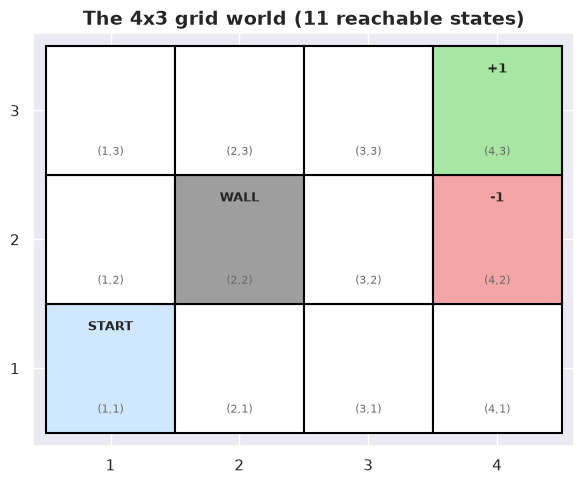

env.states (n=11): [(1, 1), (2, 1), (3, 1), (4, 1), (1, 2), (3, 2), (4, 2), (1, 3), (2, 3), (3, 3), (4, 3)]
env.terminals= {(4, 3): 1.0, (4, 2): -1.0}
env.walls= {(2, 2)}


In [29]:
# Draw the grid layout that every later algorithm will reason about.
utils.cell1_1_show_grid()

- The environment has 11 reachable states (12 cells minus 1 wall)
- Two states are terminal: reaching either ends the episode

## Cell 1.2: Stochastic action model

**Goal**:
- Show why this is an MDP and not a deterministic puzzle
- The unreliable actions are the entire source of difficulty

**Implementation**: `utils.cell1_2_stochastic_action()`

In [ ]:
hintros.print_obj_info(utils.cell1_2_stochastic_action)

In [30]:
# Create interactive widget showing the stochastic action model.
utils.cell1_2_stochastic_action()

**Usage**
- Inputs
  - **`p_intended`**: probability the intended action succeeds

- Panels
  - the grid with arrows showing where the agent can end up from the
    current state/action, weighted by probability

**Guided usage**
- Set `p_intended` to `0.8` (the default)
  - Observe the agent goes sideways 20% of the time: the intended
    direction carries probability `p_intended`, and the 2 perpendicular
    directions split the remaining mass equally
- Raise `p_intended` toward `1.0`
  - Observe the world becomes deterministic
- Point an action into a wall or the boundary
  - Observe the agent bounces back to its current cell

## Cell 1.3: Transition model as an explicit table

**Goal**:
- Make the abstract $\Pr(s' \mid s, a)$ concrete as an actual probability
  table

**Implementation**: `utils.cell1_3_show_transition_table()`,
`utils.cell1_3_transition_table()`

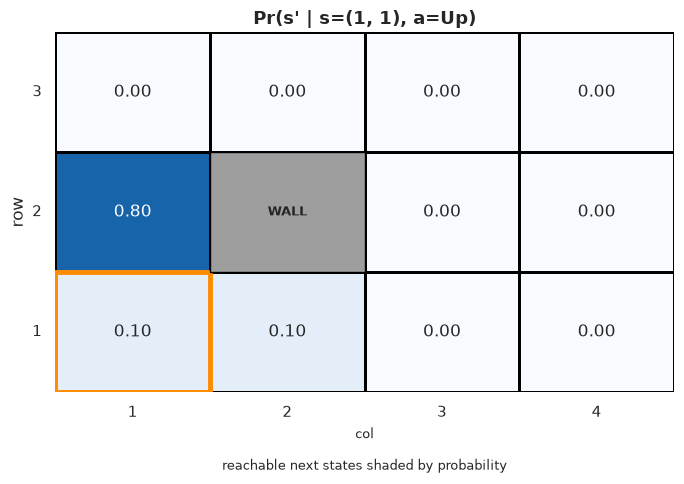

,state s,action a,next state s',"Pr(s' | s, a)"
0,"(1, 1)",Up,"(1, 2)",0.8
1,"(1, 1)",Up,"(1, 1)",0.1
2,"(1, 1)",Up,"(2, 1)",0.1


In [31]:
# Display the concrete Pr(s' | s, a) table for the START state and Up action.
utils.cell1_3_show_transition_table()

In [32]:
# Show the transition model row for a chosen state and action pair.
utils.cell1_3_transition_table()

- The transition model has shape $|S| \times |A| \times |S|$, but is
  sparse
  - Most next states have zero probability
- Each $(s, a)$ row sums to $1.0$: it is a probability distribution

**Implementation**: `utils.cell1_3_full_transition_model()`

In [ ]:
hintros.print_obj_info(utils.cell1_3_full_transition_model)

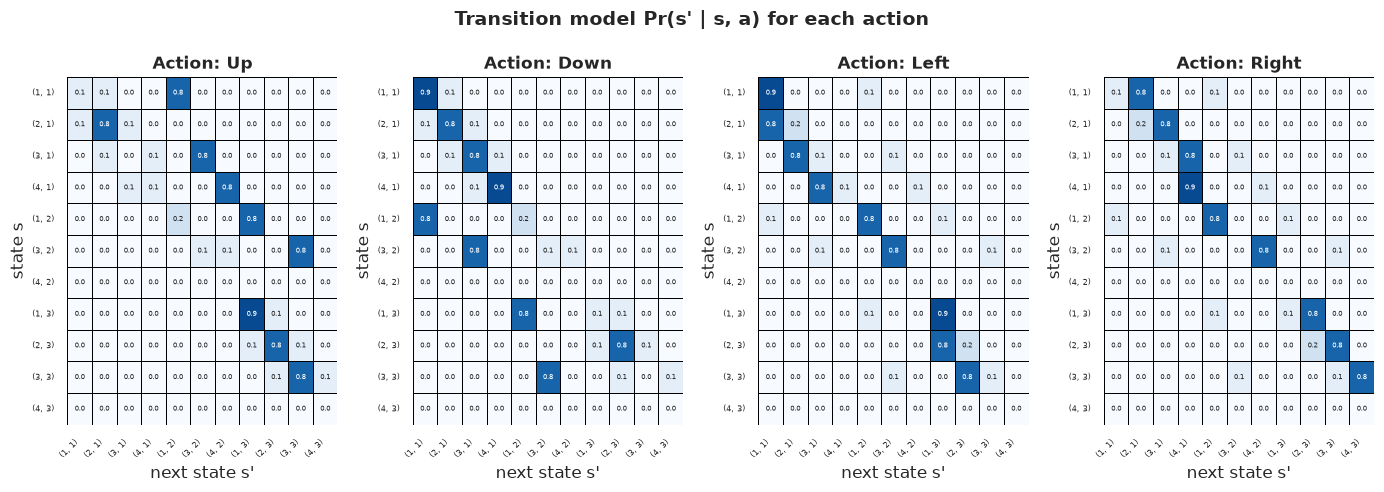


Full transition probability table:


,state,action,next state s',"Pr(s' | s, a)"
0,"(1, 1)",Up,"(1, 2)",0.8
1,"(1, 1)",Up,"(1, 1)",0.1
2,"(1, 1)",Up,"(2, 1)",0.1
3,"(1, 1)",Down,"(1, 1)",0.9
4,"(1, 1)",Down,"(2, 1)",0.1
5,"(1, 1)",Left,"(1, 1)",0.9
6,"(1, 1)",Left,"(1, 2)",0.1
7,"(1, 1)",Right,"(2, 1)",0.8
8,"(1, 1)",Right,"(1, 2)",0.1
9,"(1, 1)",Right,"(1, 1)",0.1


In [33]:
# Display the entire transition model for every state-action pair.
utils.cell1_3_full_transition_model()

**Usage**
- Inputs
  - **`state`**: the state to inspect
  - **`action`**: the action to inspect

- Panels
  - the full $\Pr(s' \mid s, a)$ row for the selected state/action pair

**Guided usage**
- Select a corner state next to 2 walls
  - Observe several next-state probabilities collapse onto the current
    cell, since both perpendicular directions bounce off a wall

## Cell 1.4: Rewards and episode returns

**Goal**:
- Define the reward structure and connect per-step rewards to
  discounted return
- Show how a single trajectory accumulates $\sum_t \gamma^t R_t$

**Implementation**: `utils.cell1_4_rewards_and_returns()`

In [ ]:
hintros.print_obj_info(utils.cell1_4_rewards_and_returns)

In [34]:
# Show per-cell rewards and the discounted return of a sample trajectory.
utils.cell1_4_rewards_and_returns()

**Usage**
- Inputs
  - **`seed`**: trajectory seed
  - **`r_step`**: living reward per step
  - **`gamma`**: discount factor

- Panels
  - the sampled trajectory over the grid, and the running discounted
    return

**Guided usage**
- Lower `r_step` further below 0
  - Observe the small negative living reward pushes the agent to finish
    quickly: each non-terminal step costs a little, so wandering is
    penalized
- Lower `gamma`
  - Observe the discount factor shrinks the contribution of later
    rewards, weighting near-term rewards more than distant ones
- Resample with a different `seed`
  - Observe the same reward/discount settings can still yield a
    different total return, since it depends on the whole sequence of
    states, not just the final cell

# Part 2: Solving the MDP with Value Iteration

## Cell 2.1: The Bellman equation for one state

**Goal**:
- Build intuition for the Bellman update on a single state
- The full algorithm is just this update applied everywhere

**Implementation**: `utils.cell2_1_bellman_one_state()`

In [37]:
# Show the value of each action at one state under converged utilities.
utils.cell2_1_bellman_one_state()

- The utility of a state is the value of its best action (not the
  average)
  - Different actions can have very different values at the same state
- Each action blends immediate reward with the discounted utility of
  next states
  - The $\max$ operator makes the system nonlinear, so we iterate
  - The greedy action is the one whose expected next-state utility is
    highest
- Repeating this max update everywhere is exactly value iteration

## Cell 2.2: The Bellman equations for all states

**Goal**:
- See the Bellman optimality equation instantiated for every grid cell
- Understand how $U(s) = \max_{a \in A(s)} \sum_{s'} \Pr(s' | s,
  a)[R(s') + \gamma U(s')]$ works out with the actual numbers

**Implementation**: `utils.cell2_2_bellman_equations()`
- For the selected state, shows the optimal action (the one that
  achieves the max), each possible next state with its probability,
  reward, and discounted utility, and the resulting utility value

In [38]:
hintros.print_obj_info(utils.cell2_2_bellman_equations)

In [ ]:
# Pick a state and gamma to see its Bellman optimality equation.
utils.cell2_2_bellman_equations()

**Usage**
- Inputs
  - **`state`**: the state whose Bellman equation to display
  - **`gamma`**: discount factor

- Panels
  - the Bellman equation for the selected state, term by term

**Guided usage**
- Select a state next to the `+1` terminal
  - Observe the term with the highest probability, reward, and
    discounted utility product dominates the sum, and the $\max$ picks
    the action leading to it
- Lower `gamma`
  - Observe every discounted-utility term shrinks, since it expresses
    each state's utility in terms of its possible next states, their
    rewards, and their discounted utilities

## Cell 2.3: Value iteration converging over sweeps

**Goal**:
- Watch state utilities converge to a fixed point as we sweep the grid
- See value information propagate backward from the terminals

**Implementation**: `utils.cell2_3_value_iteration()`

In [ ]:
hintros.print_obj_info(utils.cell2_3_value_iteration)

In [ ]:
# Step through value iteration sweeps and watch utilities converge.
utils.cell2_3_value_iteration()

**Usage**
- Inputs
  - **`iteration`**: value iteration sweep to display
  - **`gamma`**: discount factor
  - **`r_step`**: living reward

- Panels
  - the grid's utilities at the selected sweep, and how much they
    changed from the previous sweep

**Guided usage**
- Step `iteration` forward from 0
  - Observe utility spreads backward from the terminals: early sweeps
    only affect cells adjacent to the terminals, later sweeps refine the
    interior until nothing changes
- Raise `gamma`
  - Observe value propagates further but convergence takes more sweeps

## Cell 2.4: Extracting the optimal policy

**Goal**:
- Turn converged utilities into an actionable policy
- Take the greedy action in every cell

**Implementation**: `utils.cell2_4_extract_policy()`

In [ ]:
hintros.print_obj_info(utils.cell2_4_extract_policy)

In [ ]:
# Show the greedy policy extracted from converged utilities.
utils.cell2_4_extract_policy()

**Usage**
- Inputs
  - **`r_step`**: living reward
  - **`gamma`**: discount factor

- Panels
  - the grid with an arrow per cell pointing toward the action that
    maximizes expected return

**Guided usage**
- Make `r_step` a large negative number
  - Observe the agent takes the short risky path near the `-1` terminal
- Make `r_step` close to 0
  - Observe the agent takes the long safe path instead, since the
    policy is derived from utilities, not learned separately, and
    making each step expensive flips the policy toward the shorter
    risky route

# Part 3: Solving the MDP with Policy Iteration

## Cell 3.1: Policy evaluation for a fixed policy

**Goal**:
- Compute the utility of a fixed (possibly bad) policy
- This is a simpler linear problem than the full Bellman equation

When a policy `pi` is fixed (i.e., `pi(s)` specifies a single action for
each state), the Bellman equation becomes linear because the max
operator disappears.

For a fixed policy `pi`:
  $U^\pi(s) = R(s) + \gamma \sum_{s'} P(s' | s, \pi(s)) U^\pi(s')$

This is a system of $|S|$ linear equations in $|S|$ unknowns (the
utilities). It can be solved directly using linear algebra:
$(I - \gamma P) U^\pi = b$.

In contrast, the optimal Bellman equation has a max over actions:
  $U^*(s) = \max_a [R(s) + \gamma \sum_{s'} P(s' | s, a) U^*(s')]$
which is nonlinear and must be solved iteratively (value iteration).

Key insight: policy evaluation trades the hard nonlinear system for a
cheap linear one by committing to a fixed action per state first.

**Implementation**: `utils.cell3_1_policy_evaluation()`

In [ ]:
hintros.print_obj_info(utils.cell3_1_policy_evaluation)

In [39]:
# Evaluate a fixed policy by solving the linear Bellman system.
utils.cell3_1_policy_evaluation()

**Usage**
- Inputs
  - **`policy`**: which fixed policy to evaluate
  - **`gamma`**: discount factor

- Panels
  - the utility of every state under the selected fixed policy

**Guided usage**
- Select a deliberately bad `policy`
  - Observe it yields low utilities, especially where it steers into
    the `-1` terminal: evaluation answers "how good is this policy",
    not "what should I do instead", and this is the first half of
    policy iteration

## Cell 3.2: Policy improvement and iteration to optimality

**Goal**:
- Alternate evaluation and improvement until the policy stops changing
- Watch convergence to the optimal policy in a few iterations

**Implementation**: `utils.cell3_2_policy_iteration()`

In [ ]:
hintros.print_obj_info(utils.cell3_2_policy_iteration)

In [ ]:
# Step through policy iteration rounds and watch arrows flip to optimal.
utils.cell3_2_policy_iteration()

**Usage**
- Inputs
  - **`iteration`**: evaluate/improve round to display

- Panels
  - the policy arrows at the selected round

**Guided usage**
- Step `iteration` forward from 0
  - Observe each round evaluates the policy, then makes it greedy with
    respect to it; early rounds flip many arrows at once, and it
    terminates exactly when no state changes its action, often in fewer
    iterations than value iteration sweeps
- Continue past convergence
  - Observe the arrows stop changing: a stable policy is provably
    optimal

## Cell 3.3: Value iteration vs policy iteration

**Goal**:
- Contrast the two exact methods and their convergence behavior
- Understand the tradeoff between many cheap sweeps and few expensive
  rounds

**Implementation**: `utils.cell3_3_compare_solvers()`

In [ ]:
hintros.print_obj_info(utils.cell3_3_compare_solvers)

In [41]:
# Compare convergence of value iteration and policy iteration.
utils.cell3_3_compare_solvers()

**Usage**
- Inputs
  - **`gamma`**: discount factor

- Panels
  - convergence curves for value iteration (many cheap sweeps) and
    policy iteration (few expensive rounds)

**Guided usage**
- Raise `gamma` toward 1
  - Observe value iteration needs many more sweeps, while policy
    iteration's round count grows much less: both converge to the same
    optimal policy, they are just different routes to the same answer

# Part 4: Learning Without a Model (Q-Learning)

## Cell 4.1: Why reinforcement learning is harder than planning

**Goal**:
- Contrast planning (knowing the model) with learning (discovering
  through action)
- Understand why the same optimal policy takes a harder route in RL
  - Same world, blindfolded: the agent no longer has the transition
    table
  - It must learn the value of actions purely from the rewards it
    stumbles into
  - In RL the agent does not know $\Pr(s' \mid s, a)$ or $R(s, a, s')$
  - The agent only sees experience tuples $(s, a, r, s')$ as it moves
- The goal is unchanged (maximize expected return), but it must learn
  and act at the same time

**Implementation**: `utils.cell4_1_planning_vs_learning()`

In [ ]:
# Contrast the known-model and blindfolded-agent views of the same world.
utils.cell4_1_planning_vs_learning()

- Planning evaluates the model
- Learning must discover it through action
- Every later algorithm in this part sees only $(s, a, r, s')$ tuples
  - The same optimal policy is the target, reached by a harder route

## Cell 4.2: The Q-learning update rule

**Goal**:
- Introduce the single update that powers Q-learning
- Show how one experience tuple nudges a Q-value toward a better
  estimate

**Implementation**: `utils.cell4_2_q_update_rule()`

In [ ]:
hintros.print_obj_info(utils.cell4_2_q_update_rule)

In [43]:
# Show how a single experience tuple nudges a Q-value via the TD update.
utils.cell4_2_q_update_rule()

**Usage**
- Inputs
  - **`alpha`**: learning rate
  - **`gamma`**: discount factor

- Panels
  - the TD update applied to one experience tuple, before/after

**Guided usage**
- Set `alpha` near 0
  - Observe the estimate barely moves
- Set `alpha` near 1
  - Observe the estimate jumps almost all the way to the TD target: the
    TD error $r + \gamma \max_{a'} Q(s', a') - Q(s, a)$ measures
    surprise, and the update bootstraps from the current estimate of
    the next state's value

## Cell 4.3: Exploration vs exploitation with epsilon-greedy

**Goal**:
- Show why the agent must sometimes act randomly
- A purely greedy agent can lock onto a suboptimal path

**Implementation**: `utils.cell4_3_exploration()`

In [ ]:
hintros.print_obj_info(utils.cell4_3_exploration)

In [44]:
# Compare state coverage under low vs high exploration.
utils.cell4_3_exploration()

**Usage**
- Inputs
  - **`epsilon`**: exploration probability
  - **`log(n_episodes)`**: number of training episodes
  - **`seed`**: random seed

- Panels
  - a heatmap of how often the agent has visited each state

**Guided usage**
- Set `epsilon` low
  - Observe low epsilon concentrates visits on a narrow corridor of
    states: a greedy agent may never visit states off its first decent
    path
- Set `epsilon` high
  - Observe high epsilon spreads visits broadly but refines actions
    slowly, wasting episodes acting randomly; effective learning needs
    a balance, often decaying epsilon over time

## Cell 4.4: Watching Q-learning learn the optimal policy

**Goal**:
- Run full Q-learning and watch the learned policy emerge
- Compare it to the policy value iteration found with full knowledge

**Implementation**: `utils.cell4_4_q_learning_converges()`

In [ ]:
hintros.print_obj_info(utils.cell4_4_q_learning_converges)

In [45]:
# Train Q-learning and compare its policy to the value iteration optimum.
utils.cell4_4_q_learning_converges()

**Usage**
- Inputs
  - **`log(n_episodes)`**: training episodes
  - **`alpha`**: learning rate
  - **`epsilon`**: exploration probability
  - **`seed`**: random seed

- Panels
  - the learned policy arrows, and the learning curve of returns over
    episodes

**Guided usage**
- Raise `log(n_episodes)` to its max
  - Observe Q-learning recovers the same optimal policy value iteration
    found: the learned arrows converge to the value iteration policy as
    episodes grow, and returns rise and flatten as the Q-table stops
    changing
- Compare the learning curve at low vs high `log(n_episodes)`
  - Observe it is noisy early (exploration) and stabilizes as Q
    converges: model-free learning trades sample efficiency for not
    needing a model, reaching the same optimal behavior without ever
    reading the model

# Summary: The Mental Model

- An MDP is defined by states, stochastic actions $\Pr(s' \mid s, a)$,
  rewards $R(s, a, s')$, and a discount $\gamma$
  - E.g., the 4x3 grid
- When the model is known:
  - Value iteration and policy iteration compute the optimal policy
    exactly by solving the Bellman equations
- When the model is unknown
  - Q-learning learns the optimal policy from raw experience tuples
    $(s, a, r, s')$, balancing exploration and exploitation
- All three methods converge to the same optimal policy on the same
  world: the difference is whether you plan with a model or learn
  without one